In [1]:
!pip install -q torch transformers accelerate bitsandbytes

## Initial Setup:
1. Load the model in 4-bit mode.
2. Run inference on test prompts.
3. Save outputs for reproducibility.

In [2]:
import os
import json
import random
import torch

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [3]:
CONFIG = {
    "model_name": "Qwen/Qwen2.5-1.5B-Instruct",  # its a public model (LLaMa is a priv model)
    "max_new_tokens": 50,
    "temperature": 0.0,
    "top_p": 1.0,
    "seed": 42,
    "output_dir": "outputs_task1"
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

In [5]:
#compressing the 7B model to 4-bit for memory efficiency
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

In [6]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
model = AutoModelForCausalLM.from_pretrained(
    CONFIG["model_name"],
    quantization_config=bnb_config,
    device_map="auto",
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [7]:
# Some models do not have a pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

In [8]:
def generate_text(prompt, max_new_tokens=5):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

In [9]:
prompt = "The capital of France is"
result = generate_text(prompt)

print("PROMPT:")
print(prompt)
print("\nOUTPUT:")
print(result)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


PROMPT:
The capital of France is

OUTPUT:
Paris. The capital of


In [10]:
def save_run(prompt: str, output: str, config: dict, filename: str = "run_log.jsonl"):
    record = {
        "prompt": prompt,
        "output": output,
        "model_name": config["model_name"],
        "seed": config["seed"],
        "max_new_tokens": config["max_new_tokens"],
        "temperature": config["temperature"],
        "top_p": config["top_p"],
    }

    path = os.path.join(config["output_dir"], filename)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(record) + "\n")

In [11]:
save_run(prompt, result, CONFIG)

In [12]:
prompts = [
    "The capital of France is",
    "The president of the United States is",
    "The largest planet in our solar system is",
]

for p in prompts:
    out = generate_text(p)
    print("=" * 80)
    print("PROMPT:", p)
    print("OUTPUT:", out)
    save_run(p, out, CONFIG)

PROMPT: The capital of France is
OUTPUT: Paris. The capital of
PROMPT: The president of the United States is
OUTPUT: a very powerful person.
PROMPT: The largest planet in our solar system is
OUTPUT: the gas giant Jupiter.


In [13]:
def run_experiment(prompt_list, config):
    results = []
    for p in prompt_list:
        out = generate_text(
            p,
            max_new_tokens=config["max_new_tokens"],
            temperature=config["temperature"],
            top_p=config["top_p"],
        )
        record = {
            "prompt": p,
            "output": out,
        }
        results.append(record)
        save_run(p, out, config)
    return results

# Task 2: Causal Tracing and Activation Patching

Goal:
- Capture activations from each layer
- Create a corrupted run
- Patch one layer at a time
- Identify which layer restores the correct answer

In [14]:
example = {
    "prompt": "The capital of France is",
    "answer": "Paris"
}

prompt = example["prompt"]
target = example["answer"]

In [15]:
clean_activations = {}
corrupted_activations = {}

In [16]:
def save_activation(name):
    def hook(module, input, output):
        clean_activations[name] = output.detach().clone()
    return hook

In [17]:
# remove any old hooks
for layer in model.model.layers:
    layer._forward_hooks.clear()
    layer._forward_pre_hooks.clear()
    layer._backward_hooks.clear()

print("Cleared hooks")

Cleared hooks


In [18]:
clean_activations = {}
corrupted_activations = {}

In [19]:
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
        return_dict=True
    )

print("num layers:", len(model.model.layers))
print("num hidden_states:", len(outputs.hidden_states))

for i, h in enumerate(outputs.hidden_states):
    print(i, h.shape)

num layers: 28
num hidden_states: 29
0 torch.Size([1, 5, 1536])
1 torch.Size([1, 5, 1536])
2 torch.Size([1, 5, 1536])
3 torch.Size([1, 5, 1536])
4 torch.Size([1, 5, 1536])
5 torch.Size([1, 5, 1536])
6 torch.Size([1, 5, 1536])
7 torch.Size([1, 5, 1536])
8 torch.Size([1, 5, 1536])
9 torch.Size([1, 5, 1536])
10 torch.Size([1, 5, 1536])
11 torch.Size([1, 5, 1536])
12 torch.Size([1, 5, 1536])
13 torch.Size([1, 5, 1536])
14 torch.Size([1, 5, 1536])
15 torch.Size([1, 5, 1536])
16 torch.Size([1, 5, 1536])
17 torch.Size([1, 5, 1536])
18 torch.Size([1, 5, 1536])
19 torch.Size([1, 5, 1536])
20 torch.Size([1, 5, 1536])
21 torch.Size([1, 5, 1536])
22 torch.Size([1, 5, 1536])
23 torch.Size([1, 5, 1536])
24 torch.Size([1, 5, 1536])
25 torch.Size([1, 5, 1536])
26 torch.Size([1, 5, 1536])
27 torch.Size([1, 5, 1536])
28 torch.Size([1, 5, 1536])


In [20]:
clean_activations = {}

hs = outputs.hidden_states
n_layers = len(model.model.layers)

if len(hs) == n_layers + 1:
    layer_states = hs[1:]
elif len(hs) == n_layers:
    layer_states = hs
else:
    raise ValueError(f"Unexpected hidden_states length: {len(hs)}")

for i, h in enumerate(layer_states):
    clean_activations[f"layer_{i}"] = h.detach().clone()

print("captured keys:", clean_activations.keys())
print("layer_27 in dict?", "layer_27" in clean_activations)

captured keys: dict_keys(['layer_0', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7', 'layer_8', 'layer_9', 'layer_10', 'layer_11', 'layer_12', 'layer_13', 'layer_14', 'layer_15', 'layer_16', 'layer_17', 'layer_18', 'layer_19', 'layer_20', 'layer_21', 'layer_22', 'layer_23', 'layer_24', 'layer_25', 'layer_26', 'layer_27'])
layer_27 in dict? True


In [21]:
def get_target_prob(prompt, target_word):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[:, -1, :]
        probs = torch.softmax(logits, dim=-1)

    target_id = tokenizer.encode(target_word, add_special_tokens=False)[0]
    return probs[0, target_id].item()

In [22]:
clean_score = get_target_prob(prompt, target)
print("Clean score:", clean_score)

Clean score: 0.000820159912109375


In [24]:
def corrupt_activation(output):
    noise = torch.randn_like(output) * 0.1
    return output + noise

In [25]:
layer_scores = []

for i in range(len(model.model.layers)):

    # Step 1: corrupt everything
    def corrupt_hook(module, input, output):
        return corrupt_activation(output)

    corrupt_handles = []
    for layer in model.model.layers:
        h = layer.register_forward_hook(corrupt_hook)
        corrupt_handles.append(h)

    # Step 2: restore ONE layer
    def patch_hook(module, input, output):
        return clean_activations[f"layer_{i}"]

    patch_handle = model.model.layers[i].register_forward_hook(patch_hook)

    # Step 3: run model
    score = get_target_prob(prompt, target)

    layer_scores.append({
        "layer": i,
        "score": score
    })

    # Step 4: remove hooks
    patch_handle.remove()
    for h in corrupt_handles:
        h.remove()

print("Done")

Done


In [26]:
import pandas as pd

df = pd.DataFrame(layer_scores)
df.head()

,layer,score
0,0,0.000239
1,1,0.000874
2,2,0.000561
3,3,0.000675
4,4,0.000431


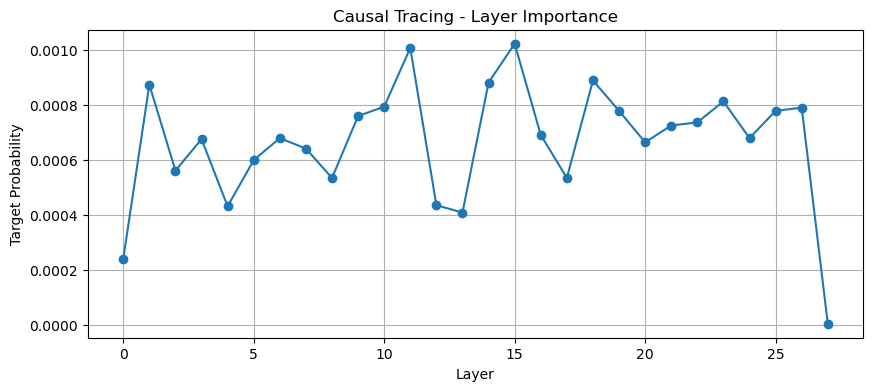

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df["layer"], df["score"], marker="o")
plt.xlabel("Layer")
plt.ylabel("Target Probability")
plt.title("Causal Tracing - Layer Importance")
plt.grid(True)
plt.show()

In [28]:
best_layer = df.loc[df["score"].idxmax()]

print("Best layer:")
print(best_layer)

Best layer:
layer    15.000000
score     0.001022
Name: 15, dtype: float64
